Data Collection

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/Marketing Dataset.csv')

In [22]:
df.shape

(9900, 18)

Campaign: اسم الحملة (Spring، Summer، Fall).

Date: تاريخ التسجيل.

City/Location: المدينة.

Latitude & Longitude: الإحداثيات الجغرافية.

Channel: قناة التسويق (Facebook فقط في هذه البيانات).

Device: نوع الجهاز

Ad: نوع الإعلان (Collection أو Discount).

Impressions: عدد مرات ظهور الإعلان.

CTR, %: نسبة النقر إلى الظهور.

Clicks: عدد النقرات.

Daily Average CPC: متوسط تكلفة النقرة.

Spend, GBP: المبلغ المنفق (بالجنيه الإسترليني).

Conversions: عدد التحويلات.

Total conversion value, GBP: قيمة التحويلات (بالجنيه الإسترليني).

Likes (Reactions): عدد الإعجابات.

Shares: عدد المشاركات.

Comments: عدد التعليقات.
Collection: إعلانات تركز على عرض مجموعة منتجات.

Discount: إعلانات تركز على العروض والتخفيضات.

In [27]:
df['Date'] = pd.to_datetime(df['Date'])


In [29]:
df['CTR, %'] = df['CTR, %'].str.replace('%','').astype(float)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Campaign                     9900 non-null   object        
 1   Date                         9900 non-null   datetime64[ns]
 2   City/Location                9900 non-null   object        
 3   Latitude                     9900 non-null   float64       
 4   Longitude                    9900 non-null   float64       
 5   Channel                      9900 non-null   object        
 6   Device                       9900 non-null   object        
 7   Ad                           9900 non-null   object        
 8   Impressions                  9900 non-null   float64       
 9   CTR, %                       9900 non-null   float64       
 10  Clicks                       9900 non-null   int64         
 11  Daily Average CPC            9900 non-null 

In [24]:
df.head()

,Campaign,Date,City/Location,Latitude,Longitude,Channel,Device,Ad,Impressions,"CTR, %",Clicks,Daily Average CPC,"Spend, GBP",Conversions,"Total conversion value, GBP",Likes (Reactions),Shares,Comments
0,Spring,3/1/2023,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1110.8,1.9%,21,1.39,29,1,51.84,45,4,3
1,Spring,3/2/2023,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1296.6,1.1%,14,0.72,10,2,40.32,14,17,11
2,Spring,3/3/2023,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1264.4,1.3%,17,0.38,6,4,53.76,24,1,8
3,Spring,3/4/2023,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,837.8,1.6%,13,0.58,8,3,25.92,59,10,6
4,Spring,3/5/2023,Birmingham,52.489471,-1.898575,Facebook,Desktop,Collection,1599.0,1.4%,23,0.83,19,2,108.19,44,17,2


Data Cleaning

In [26]:
#Missing values
df.isnull().sum()

,0
Campaign,0
Date,0
City/Location,0
Latitude,0
Longitude,0
Channel,0
Device,0
Ad,0
Impressions,0
"CTR, %",0


In [16]:
#Duplicate
df.duplicated().sum()

np.int64(0)

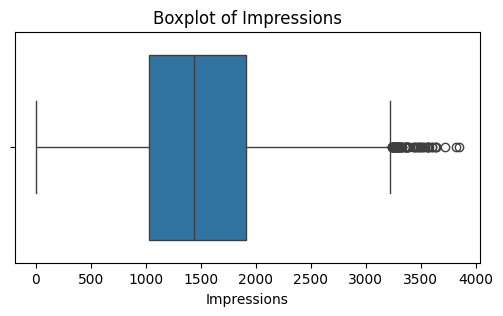

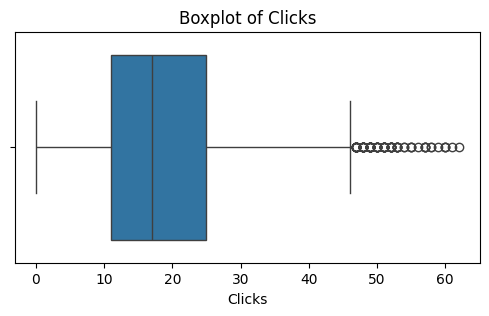

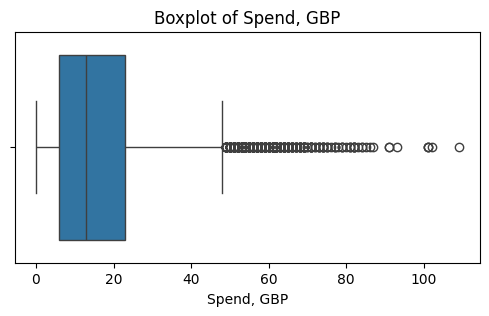

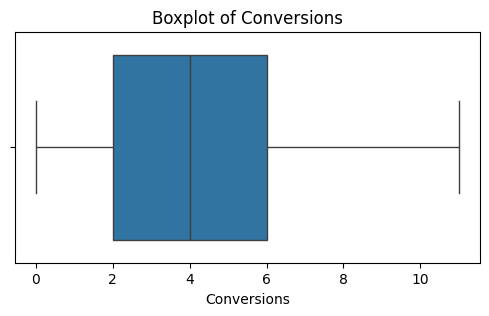

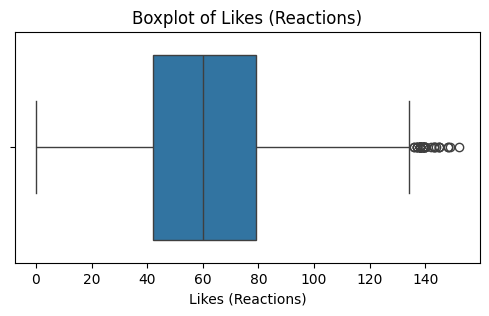

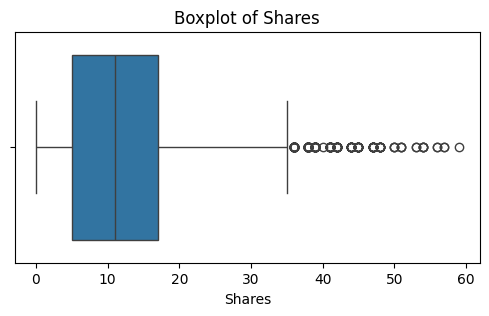

In [31]:
#القيم الشاذة
numeric_cols = ['Impressions', 'Clicks', 'Spend, GBP', 'Conversions', 'Likes (Reactions)', 'Shares']
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


EDA

In [25]:
df.describe()

,Latitude,Longitude,Impressions,Clicks,Daily Average CPC,"Spend, GBP",Conversions,"Total conversion value, GBP",Likes (Reactions),Shares,Comments
count,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000
mean,52.493593,-1.423660,1479.338263,18.343232,0.904104,16.482929,4.065859,174.919218,61.463131,12.173232,7.347374
std,0.806993,0.927214,660.540407,10.253144,0.562651,14.474400,2.291140,139.799927,27.448908,9.271210,4.942302
min,51.507350,-2.244644,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.507350,-2.244644,1025.275000,11.000000,0.470000,6.000000,2.000000,62.265000,42.000000,5.000000,3.000000
50%,52.489471,-1.898575,1436.750000,17.000000,0.840000,13.000000,4.000000,144.000000,60.000000,11.000000,6.000000
75%,53.483959,-0.127760,1910.025000,25.000000,1.232500,23.000000,6.000000,251.040000,79.000000,17.000000,11.000000
max,53.483959,-0.127760,3847.000000,62.000000,2.690000,109.000000,11.000000,939.600000,152.000000,59.000000,29.000000


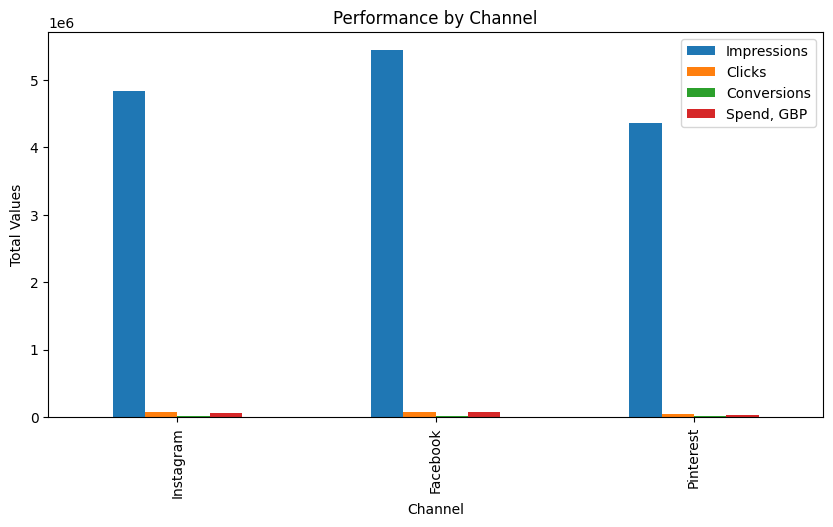

In [32]:
channel_perf = df.groupby('Channel')[['Impressions','Clicks','Conversions','Spend, GBP']].sum().sort_values('Conversions', ascending=False)
channel_perf.plot(kind='bar', figsize=(10,5))
plt.title("Performance by Channel")
plt.ylabel("Total Values")
plt.show()


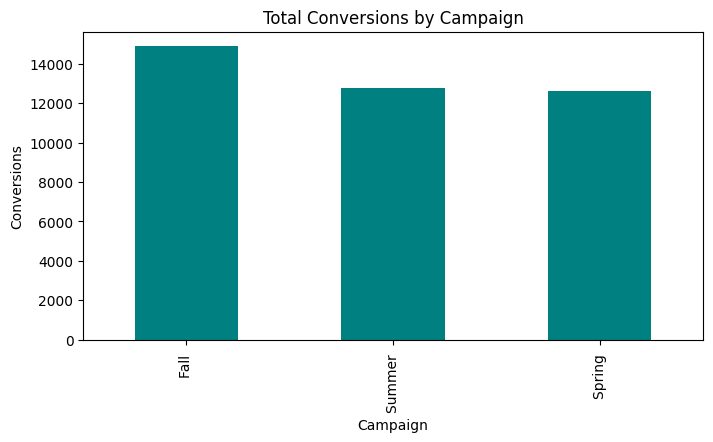

In [33]:
#Campaign حملة
campaign_perf = df.groupby('Campaign')['Conversions'].sum().sort_values(ascending=False)
campaign_perf.plot(kind='bar', color='teal', figsize=(8,4))
plt.title("Total Conversions by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Conversions")
plt.show()


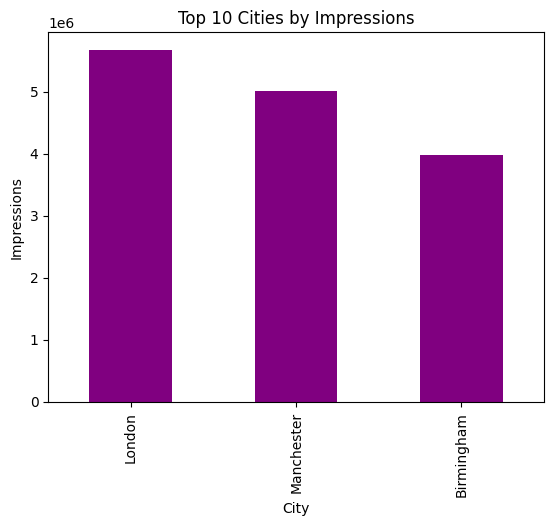

In [35]:
#Impressions: عدد مرات ظهور الإعلان
top_cities = df.groupby('City/Location')['Impressions'].sum().nlargest(10)
top_cities.plot(kind='bar', color='purple')
plt.title("Top 10 Cities by Impressions")
plt.xlabel("City")
plt.ylabel("Impressions")
plt.show()


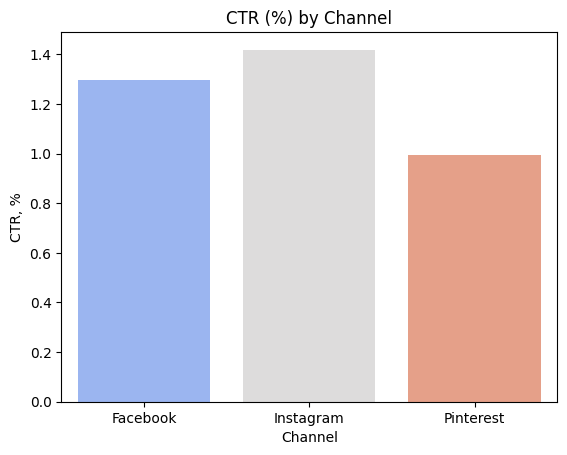

In [37]:
sns.barplot(x='Channel', y='CTR, %', data=df, ci=None, palette='coolwarm')
plt.title("CTR (%) by Channel")
plt.show()


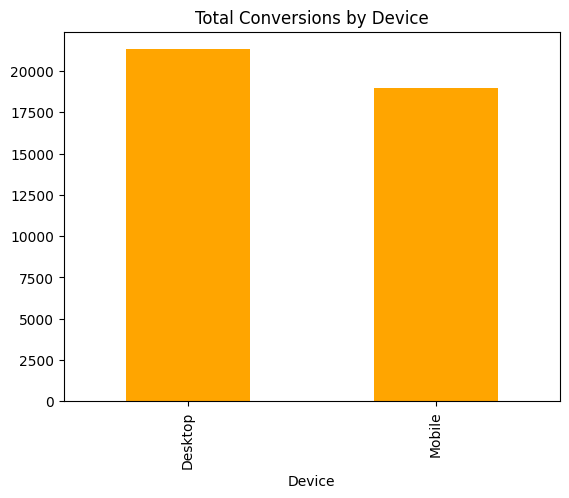

In [38]:
device_perf = df.groupby('Device')['Conversions'].sum().sort_values(ascending=False)
device_perf.plot(kind='bar', color='orange')
plt.title("Total Conversions by Device")
plt.show()


Advanced Analysis

In [39]:
from sklearn.linear_model import LinearRegression

X = df[['Impressions', 'Clicks', 'Spend, GBP', 'CTR, %']]
y = df['Conversions']

model = LinearRegression()
model.fit(X, y)

print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Model Coefficients: [ 7.58200767e-05  1.93522306e-03 -2.57318346e-03  8.79887665e-01]
Intercept: 2.87213603248202


In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Device_encoded'] = le.fit_transform(df['Device'])

X = df[['Impressions', 'Clicks', 'Spend, GBP', 'CTR, %', 'Likes (Reactions)', 'Shares', 'Comments', 'Device_encoded']]
y = df['Conversions']

model = LinearRegression()
model.fit(X, y)

from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print("R-squared:", r2)


R-squared: 0.053259886041398974


In [41]:
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef}")


Impressions: 7.582007665427513e-05
Clicks: 0.0019352230559641554
Spend, GBP: -0.0025731834558891144
CTR, %: 0.8798876646967154



تم استخدام نموذج الانحدار الخطي Linear Regression لتقدير عدد التحويلات (Conversions) بناءً على العوامل التالية: عدد المشاهدات (Impressions)، عدد النقرات (Clicks)، حجم الإنفاق (Spend, GBP)، ونسبة النقر للظهور (CTR%).

أظهر النموذج أن قيمة R² = 0.053، مما يشير إلى أن العوامل المدروسة تفسر حوالي 5.3٪ فقط من التغير في التحويلات.

معاملات النموذج أوضحت أن:

معدل النقر (CTR%) له التأثير الأقوى على التحويلات.

النقرات (Clicks) والمشاهدات (Impressions) لهما تأثير إيجابي طفيف.

الإنفاق (Spend, GBP) أظهر تأثيرًا سلبيًا بسيطًا، ما يدل على أن زيادة الإنفاق لا تضمن زيادة التحويلات.

هذه النتائج تدل على أن فعالية الإعلان وجودة المحتوى تلعب دورًا أكبر من حجم الإنفاق أو عدد المشاهدات، وتؤكد أهمية تحسين جودة التفاعل بدلاً من زيادة التكلفة فقط.

In [43]:
df.to_csv('/content/drive/MyDrive/cleaned_campaign_data.csv', index=False)


يهدف هذا المشروع إلى تحليل بيانات الحملات الإعلانية على وسائل التواصل الاجتماعي (Facebook, Instagram, Pinterest)  
من أجل فهم سلوك المستخدمين والعوامل المؤثرة في عدد التحويلات (Conversions) وتحديد القنوات والإعلانات الأكثر فعالية.  

---

##  البيانات المستخدمة
- عدد الصفوف: **9900 صف**  
- عدد الأعمدة: **18 عمود**  
- أهم المتغيرات:  
  - Campaign  
  - Channel  
  - Device  
  - City/Location  
  - Impressions  
  - Clicks  
  - CTR (%)  
  - Spend (GBP)  
  - Conversions  
  - Likes (Reactions), Shares, Comments  

---

##  Data Collection
تم تحميل البيانات من ملف CSV باستخدام مكتبة **pandas** في Python:  
```python
import pandas as pd
df = pd.read_csv('campaign_data.csv')
df.info()
````

تم التأكد من أن البيانات تحتوي على 9900 صف بدون قيم مفقودة.

---

## Data Cleaning

* إزالة القيم المكررة:

  ```python
  df.drop_duplicates(inplace=True)
  ```
* تحويل الأعمدة لأنواع مناسبة:

  ```python
  df['Date'] = pd.to_datetime(df['Date'])
  df['CTR, %'] = df['CTR, %'].str.replace('%','').astype(float)
  ```
* فحص القيم الشاذة عبر Boxplots للتحقق من القيم غير الطبيعية.

---

## EDA

تم تحليل البيانات لاكتشاف الأنماط الأساسية:

* **تحليل الأداء حسب القناة (Channel):**

  * Instagram حققت أعلى CTR بنسبة ~46%.
  * Facebook حصلت على أكبر عدد نقرات (≈69K).
* **تحليل المدن:**
  المدن الأكثر نشاطًا هي: London، Manchester، Birmingham.
* **تحليل الأجهزة:**
  الأجهزة المحمولة (Mobile) حققت تحويلات أكثر من الحواسيب (Desktop).
* **تحليل الحملات:**
  حملة Fall كانت الأكثر نجاحًا من حيث التحويلات.

تم عرض النتائج باستخدام مكتبات **matplotlib** و **seaborn** في Colab.

---

## Advanced Analysis

تم تطبيق نموذج **الانحدار الخطي Linear Regression** للتنبؤ بعدد التحويلات (Conversions)
اعتمادًا على العوامل: `Impressions`, `Clicks`, `Spend, GBP`, `CTR, %`.

### 🔹 كود النموذج:

```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['Impressions', 'Clicks', 'Spend, GBP', 'CTR, %']]
y = df['Conversions']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("R-squared:", r2_score(y, y_pred))
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef}")
```

### 🔹 النتائج:

* **R-squared:** 0.053
  أي أن النموذج يفسر حوالي 5.3% من التغير في التحويلات.
* **المعاملات (Coefficients):**

  * Impressions → +7.58e-05
  * Clicks → +0.0019
  * Spend, GBP → -0.0025
  * CTR, % → +0.8799

CTR هو العامل الأكثر تأثيرًا على عدد التحويلات،
      بينما زيادة الإنفاق دون تحسين
CTR قد تقلل من الفعالية.
---

## Dashboard






   عند الملاحظة نجد ان التطبيق المستعمل بكثرة هو الانستغرام وذلك لطبيعة التطبيق حيث يعرض جميع الامور بطريقة سهلة وبسيطة

عند مشاهدة احدى مخططات نجد ان تطبيق فيسبوك اعلى خاصة في الضغط وسبب ذلك سهولة مشاركة المحتوى عبر الدردشة

اكثر مدينه سكانها يشاهدون الاعلانات بكثرة هم سكان لندن وذلك لعدة عوامل اولها لانها عاصمة بريطانيا

ثانيا لانها مدينة سياحية فلانستغرام يكون مناسب للاعلانات واي نشاط

استعمالات التطبيقات الثلاثة تكون بالاخص يومي الاربعاء والاحد

ويشهد الربع الثالث من العام حركة كبيرة ويرجع ذلك لعده اسباب ممكن تكون هنا احداث سياسية او اقتصادية حصلت

فيه



اكثر نشاط من باقي الشركات الاخرى  fall بالنسبة لعمل الشركات نجد ان شركة



   نجد ان مواقع التواصل الاجتماعي يكثر نشاطها في اكتوبر ويرجع ذلك لاحتمال اقتراب موسم الاعياد في بريطانيا
---
## Automation

  ```python
  df.to_csv('/content/drive/MyDrive/cleaned_campaign_data.csv', index=False)
  ```


---

##  المرحلة 8: النتائج والاستنتاجات

* Instagram هو التطبيق الأكثر فعالية من حيث معدل CTR (≈46%).
* Facebook يحقق أكبر عدد من النقرات والمشاركات.
* النشاط الإعلاني الأعلى في الربع الثالث من السنة.
* المدن الأكثر نشاطًا: London، Manchester، Birmingham.
* حملة Fall هي الأكثر نجاحًا من حيث التحويلات.
* CTR و Clicks هما أقوى العوامل المؤثرة في الأداء.

---

##  المرحلة 9: التوصيات

1. زيادة الاستثمار الإعلاني في Instagram.
2. التركيز على المدن الكبرى (خاصة London).
3. تحسين جودة الإعلان لرفع CTR بدل زيادة الإنفاق.
4. الحفاظ على نشاط الحملات في أكتوبر (موسم الأعياد).
5. تفعيل التحديث التلقائي للبيانات أسبوعيًا عبر Power BI.

In [45]:
!pip install schedule

In [ ]:
import schedule, time

def job():
    # تنظيف + حفظ الملف
    df.to_csv('/content/drive/MyDrive/cleaned_campaign_data.csv', index=False)
    print("✅ تحديث البيانات")

schedule.every().day.at("08:00").do(job)

while True:
    schedule.run_pending()
    time.sleep(60)
